<a href="https://colab.research.google.com/github/mogesTesema/Machine-Learning-Mastery-With-TensorFlow/blob/main/05_transfer_learning_in_tensorflow_part_2_Fine_Tuning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Transfer Learning with tensorflow part 2: Fine-Tuning

## Creating helper functions

In [2]:
!wget https://raw.githubusercontent.com/mrdbourke/tensorflow-deep-learning/refs/heads/main/extras/helper_functions.py

--2026-01-31 12:05:33--  https://raw.githubusercontent.com/mrdbourke/tensorflow-deep-learning/refs/heads/main/extras/helper_functions.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.110.133, 185.199.109.133, 185.199.111.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.110.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 10246 (10K) [text/plain]
Saving to: ‘helper_functions.py.1’

helper_functions.py 100%[===================>]  10.01K  --.-KB/s    in 0s      

2026-01-31 12:05:33 (129 MB/s) - ‘helper_functions.py.1’ saved [10246/10246]



In [3]:
from helper_functions import plot_loss_curves,create_tensorboard_callback,confusion_matrix,load_and_prep_image,walk_through_dir,unzip_data

## Let's get some data

In [4]:
!wget https://storage.googleapis.com/ztm_tf_course/food_vision/10_food_classes_10_percent.zip

--2026-01-31 12:05:43--  https://storage.googleapis.com/ztm_tf_course/food_vision/10_food_classes_10_percent.zip
Resolving storage.googleapis.com (storage.googleapis.com)... 108.177.96.207, 108.177.119.207, 108.177.127.207, ...
Connecting to storage.googleapis.com (storage.googleapis.com)|108.177.96.207|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 168546183 (161M) [application/zip]
Saving to: ‘10_food_classes_10_percent.zip’

10_food_classes_10_ 100%[===================>] 160.74M  39.2MB/s    in 5.0s    

2026-01-31 12:05:48 (32.2 MB/s) - ‘10_food_classes_10_percent.zip’ saved [168546183/168546183]



In [5]:
unzip_data('10_food_classes_10_percent.zip')

In [6]:
walk_through_dir("10_food_classes_10_percent")

There are 2 directories and 0 images in '10_food_classes_10_percent'.
There are 10 directories and 0 images in '10_food_classes_10_percent/test'.
There are 0 directories and 250 images in '10_food_classes_10_percent/test/chicken_curry'.
There are 0 directories and 250 images in '10_food_classes_10_percent/test/ramen'.
There are 0 directories and 250 images in '10_food_classes_10_percent/test/ice_cream'.
There are 0 directories and 250 images in '10_food_classes_10_percent/test/pizza'.
There are 0 directories and 250 images in '10_food_classes_10_percent/test/steak'.
There are 0 directories and 250 images in '10_food_classes_10_percent/test/fried_rice'.
There are 0 directories and 250 images in '10_food_classes_10_percent/test/hamburger'.
There are 0 directories and 250 images in '10_food_classes_10_percent/test/grilled_salmon'.
There are 0 directories and 250 images in '10_food_classes_10_percent/test/chicken_wings'.
There are 0 directories and 250 images in '10_food_classes_10_percent

In [7]:
# Create training and test directory paths
train_dir = "/content/10_food_classes_10_percent/train"
test_dir = "/content/10_food_classes_10_percent/test"


In [8]:
import tensorflow as tf

In [9]:
IMG_SIZE = (224,224)
BATCH_SIZE = 32
train_data_10_percent = tf.keras.preprocessing.image_dataset_from_directory(directory=train_dir,
                                                                            image_size=IMG_SIZE,
                                                                            label_mode='categorical',
                                                                            batch_size=BATCH_SIZE
                                                                            )
test_data = tf.keras.preprocessing.image_dataset_from_directory(directory=test_dir,
                                                                image_size=IMG_SIZE,
                                                                batch_size=BATCH_SIZE,
                                                                label_mode="categorical")


Found 750 files belonging to 10 classes.


Found 2500 files belonging to 10 classes.


In [10]:
train_data_10_percent

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 10), dtype=tf.float32, name=None))>

In [11]:
train_data_10_percent.class_names

['chicken_curry',
 'chicken_wings',
 'fried_rice',
 'grilled_salmon',
 'hamburger',
 'ice_cream',
 'pizza',
 'ramen',
 'steak',
 'sushi']

In [12]:
for images,labels in train_data_10_percent.take(1):
  print(images,labels)

tf.Tensor(
[[[[165.57143    79.57143    20.571428 ]
   [171.5759     85.5759     24.626276 ]
   [175.29433    90.29432    26.155613 ]
   ...
   [  3.1384146   7.138415    6.138415 ]
   [  3.705357    7.705357    6.705357 ]
   [  3.3526785   7.352679    6.352679 ]]

  [[162.52232    78.30197    19.427296 ]
   [168.50479    84.62086    22.879784 ]
   [173.18112    89.18112    25.297195 ]
   ...
   [  3.9295292   7.929529    6.929529 ]
   [  4.937818    8.937818    7.937818 ]
   [  4.5474796   8.54748     7.5474796]]

  [[150.85747    69.62086    13.14764  ]
   [158.15083    77.623085   18.583866 ]
   [168.55325    86.08004    25.606825 ]
   ...
   [  2.1859107   6.1859107   5.1859107]
   [  3.2197034   7.2197037   6.2197037]
   [  2.727333    6.727333    5.727333 ]]

  ...

  [[ 38.33472    67.31725   113.41485  ]
   [ 70.464005  100.24427   154.43182  ]
   [ 53.06273    81.75792   141.49294  ]
   ...
   [ 85.69626    43.867535   16.639593 ]
   [ 75.41873    35.41873     9.418731 ]
   [ 

In [13]:
resNet_model = tf.keras.applications.ResNet50(include_top=False,weights='imagenet',input_shape=(224,224,3))


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


In [14]:
resNet_weights = resNet_model.get_weights()




In [15]:
resNet_model.compile(loss='categorical_crossentropy',
                     optimizer='adam',
                     metrics=['accuracy'])
# resNet_model.fit(train_data_10_percent,epochs=3)

## Creating the model using functional API.
what is functional API actually

In [16]:
def getMe():
  def hello(name):
    return f"hello {name} functional API"
  return hello

result = getMe()("Keras")
print(result)

hello Keras functional API


## Modle 0: Building a transfer learning model using the Keras Functional API



In [17]:
# 1. Create the base model with tf.keras.applications.resNet50
base_model = tf.keras.applications.EfficientNetB0(include_top=False)

# 2. Freeze the base model (so the underling pre-trained patterns aren't updated durring training)
base_model.trainable = False

# 3. Create inputs into our model
inputs = tf.keras.layers.Input(shape=(224,224,3), name="input_layer")

# 4. If you using a model like ResNet50V2 you will need to normalize inputs
# x = tf.keras.layers.experimental.preprocessing.Rescaling(1/255.)(inputs)

# 5. Pass the inputs to the base_model
x = base_model(inputs)
print(f"Shape after passing inputs through base model: {x.shape}")

# 6. Average pool the outputs of the base model (aggregate all the the most important information reduce number of computations)
x = tf.keras.layers.GlobalAveragePooling2D(name="global_average_pooling_layer")(x)
print(f"Shape after global average 2D: {x.shape}")

# 7. Create the output activation layer
outputs = tf.keras.layers.Dense(10,activation="softmax",name="output_layer")(x)

# 8. Combine the inputs with the outputs into a model
model_0 = tf.keras.Model(inputs,outputs)

# 9. compile the model
model_0.compile(loss="categorical_crossentropy",
                optimizer=tf.keras.optimizers.Adam(),
                metrics=["accuracy"])

# 10. Fit the model and save its history
model_0_history = model_0.fit(train_data_10_percent,
                              epochs=5,
                              steps_per_epoch=len(train_data_10_percent),
                              validation_data= test_data,
                              validation_steps= len(test_data),
                              callbacks=[create_tensorboard_callback("TensorFlow_Hub","Fine_tuned_EfficientNet")]
                              )




16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Shape after passing inputs through base model: (None, 7, 7, 1280)
Shape after global average 2D: (None, 1280)
Saving TensorBoard log files to: TensorFlow_Hub/Fine_tuned_EfficientNet/20260131-120606
Epoch 1/5
24/24 ━━━━━━━━━━━━━━━━━━━━ 71s 2s/step - accuracy: 0.2088 - loss: 2.2244 - val_accuracy: 0.7148 - val_loss: 1.3623
Epoch 2/5
24/24 ━━━━━━━━━━━━━━━━━━━━ 7s 283ms/step - accuracy: 0.7257 - loss: 1.2554 - val_accuracy: 0.8244 - val_loss: 0.8855
Epoch 3/5
24/24 ━━━━━━━━━━━━━━━━━━━━ 10s 279ms/step - accuracy: 0.8301 - loss: 0.8478 - val_accuracy: 0.8436 - val_loss: 0.7047
Epoch 4/5
24/24 ━━━━━━━━━━━━━━━━━━━━ 6s 277ms/step - accuracy: 0.8412 - loss: 0.6521 - val_accuracy: 0.8552 - val_loss: 0.6128
Epoch 5/5
24/24 ━━━━━━━━━━━━━━━━━━━━ 10s 275ms/step - accuracy: 0.8508 - loss: 0.5947 - val_accuracy: 0.8584 - val_loss: 0.5556


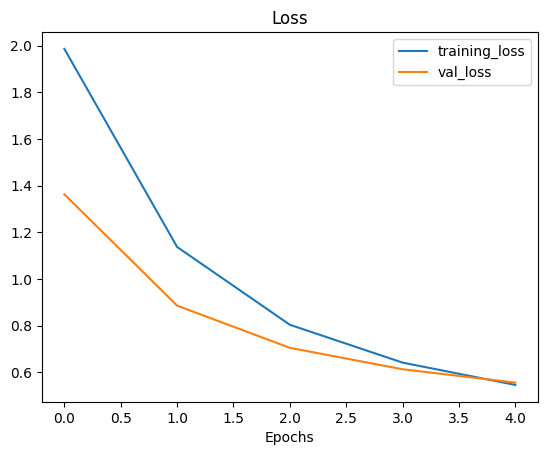

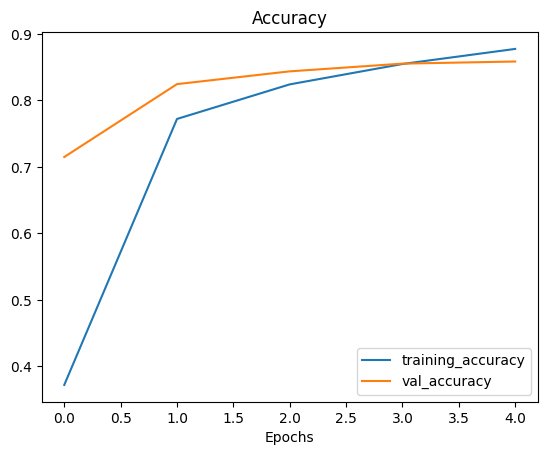

In [18]:
plot_loss_curves(model_0_history)

In [19]:
# Evaluate the tuned model
model_0.evaluate(test_data)

79/79 ━━━━━━━━━━━━━━━━━━━━ 4s 54ms/step - accuracy: 0.8579 - loss: 0.5544


[0.5555950403213501, 0.8583999872207642]

In [20]:
for layer_number, layer in enumerate(base_model.layers):
  print(layer_number,layer.name)

0 input_layer_1
1 rescaling
2 normalization
3 rescaling_1
4 stem_conv_pad
5 stem_conv
6 stem_bn
7 stem_activation
8 block1a_dwconv
9 block1a_bn
10 block1a_activation
11 block1a_se_squeeze
12 block1a_se_reshape
13 block1a_se_reduce
14 block1a_se_expand
15 block1a_se_excite
16 block1a_project_conv
17 block1a_project_bn
18 block2a_expand_conv
19 block2a_expand_bn
20 block2a_expand_activation
21 block2a_dwconv_pad
22 block2a_dwconv
23 block2a_bn
24 block2a_activation
25 block2a_se_squeeze
26 block2a_se_reshape
27 block2a_se_reduce
28 block2a_se_expand
29 block2a_se_excite
30 block2a_project_conv
31 block2a_project_bn
32 block2b_expand_conv
33 block2b_expand_bn
34 block2b_expand_activation
35 block2b_dwconv
36 block2b_bn
37 block2b_activation
38 block2b_se_squeeze
39 block2b_se_reshape
40 block2b_se_reduce
41 block2b_se_expand
42 block2b_se_excite
43 block2b_project_conv
44 block2b_project_bn
45 block2b_drop
46 block2b_add
47 block3a_expand_conv
48 block3a_expand_bn
49 block3a_expand_activa

In [21]:
base_model.summary()

Model: "efficientnetb0"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, None,      │          0 │ -                 │
│ (InputLayer)        │ None, 3)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, None,      │          0 │ input_layer_1[0]… │
│ (Rescaling)         │ None, 3)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, None,      │          7 │ rescaling[0][0]   │
│ (Normalization)     │ None, 3)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, None,      │          0 │ normalization[0]… │
│ (Rescaling)         │ None, 3)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, None,      │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ None, 3)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, None,      │        864 │ stem_conv_pad[0]… │
│                     │ None, 32)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, None,      │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ None, 32)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, None,      │          0 │ stem_bn[0][0]     │
│ (Activation)        │ None, 32)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, None,      │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ None, 32)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, None,      │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ None, 32)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, None,      │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ None, 32)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, None,      │          0 │ block1a_activati… │
│ (Multiply)          │ None, 32)         │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, None,      │        512 │ block1a_se_excit

 Total params: 4,049,571 (15.45 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 4,049,571 (15.45 MB)

In [22]:
# tf.keras.utils.plot_model(base_model)

In [23]:
model_0.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling_layer    │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 10)             │        12,810 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,088,003 (15.59 MB)

 Trainable params: 12,810 (50.04 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

 Optimizer params: 25,622 (100.09 KB)

## Getting a feature vector from a trained model

In [24]:
# # Define the input shape
# input_shape = (1,4,4,3)
# # Create a random tensor
# tf.random.set_seed(42)
# input_tensor = tf.random.normal(input_shape)
# # pass the random tensor through a global average pooling 2D layer
# global_average_pooled_tensor = tf.keras.layers.GlobalAveragePooling2D(input_tensor)
# global_average_pooled_tensor

## Running a series of transfer learning experiments
we've seen the incredible results transfer learning can get with only 10% of the training data, but how does it go with 1% of the training data.. how about we set up a bunch of experiments to find out:
1. `model_1`  - use feature extracion transfer learning with 1% of the training data with data augmentation
2. `model_2` - use feature extracctio transfer learning with 10% of the training data with data augmentation
3. `model_3` - use fine-tuning transfer learning on 10% of the training data with data augmentation
4. `model_4` - use fine-turning transfer learning on 100% of the training data with data augmentation
**Note:** throught all experiments the same test dataset will be used to evaluate our model.. this ensures consisency across evaluation metrics.


In [25]:
!wget https://storage.googleapis.com/ztm_tf_course/food_vision/10_food_classes_1_percent.zip

--2026-01-31 12:08:02--  https://storage.googleapis.com/ztm_tf_course/food_vision/10_food_classes_1_percent.zip
Resolving storage.googleapis.com (storage.googleapis.com)... 108.177.96.207, 108.177.119.207, 108.177.127.207, ...
Connecting to storage.googleapis.com (storage.googleapis.com)|108.177.96.207|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 133612354 (127M) [application/zip]
Saving to: ‘10_food_classes_1_percent.zip’

10_food_classes_1_p 100%[===================>] 127.42M  36.5MB/s    in 4.1s    

2026-01-31 12:08:06 (31.3 MB/s) - ‘10_food_classes_1_percent.zip’ saved [133612354/133612354]



In [26]:
unzip_data("10_food_classes_1_percent.zip")

In [27]:
walk_through_dir("10_food_classes_1_percent")

There are 2 directories and 0 images in '10_food_classes_1_percent'.
There are 10 directories and 0 images in '10_food_classes_1_percent/test'.
There are 0 directories and 250 images in '10_food_classes_1_percent/test/chicken_curry'.
There are 0 directories and 250 images in '10_food_classes_1_percent/test/ramen'.
There are 0 directories and 250 images in '10_food_classes_1_percent/test/ice_cream'.
There are 0 directories and 250 images in '10_food_classes_1_percent/test/pizza'.
There are 0 directories and 250 images in '10_food_classes_1_percent/test/steak'.
There are 0 directories and 250 images in '10_food_classes_1_percent/test/fried_rice'.
There are 0 directories and 250 images in '10_food_classes_1_percent/test/hamburger'.
There are 0 directories and 250 images in '10_food_classes_1_percent/test/grilled_salmon'.
There are 0 directories and 250 images in '10_food_classes_1_percent/test/chicken_wings'.
There are 0 directories and 250 images in '10_food_classes_1_percent/test/sushi'

In [28]:
train_dir_1_percent = "10_food_classes_1_percent/train"
test_dir = "10_food_classes_1_percent/test"


In [29]:
# Set up data loader
IMG_SIZE = (224,224)
BATCH_SIZE = 32
train_data_1_percent = tf.keras.preprocessing.image_dataset_from_directory(directory=train_dir_1_percent,
                                                             image_size=IMG_SIZE,
                                                             label_mode="categorical",
                                                             batch_size=BATCH_SIZE,
                                                             )
test_data = tf.keras.preprocessing.image_dataset_from_directory(directory=test_dir,
                                                  image_size=IMG_SIZE,
                                                  batch_size=BATCH_SIZE,
                                                  label_mode="categorical",
                                                  )

Found 70 files belonging to 10 classes.
Found 2500 files belonging to 10 classes.


In [30]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras import preprocessing


In [31]:
data_augmentation = tf.keras.Sequential([
    # tf.keras.layers.Rescaling(1/255.), # EfficientNet has rescaling built-in
    # tf.keras.layers.Input(shape=(224,224,3)),
    tf.keras.layers.RandomFlip('horizontal'),
    tf.keras.layers.RandomRotation(0.2),
    tf.keras.layers.RandomHeight(0.2),
    tf.keras.layers.RandomWidth(0.2),
    # tf.keras.layers.RandomErasing(factor=1,scale=(0.02,0.03)),
    tf.keras.layers.RandomZoom(height_factor=(0.1,0.15)),
    ],name="data_augmentation")

(334, 563, 3)


(np.float64(-0.5), np.float64(562.5), np.float64(333.5), np.float64(-0.5))

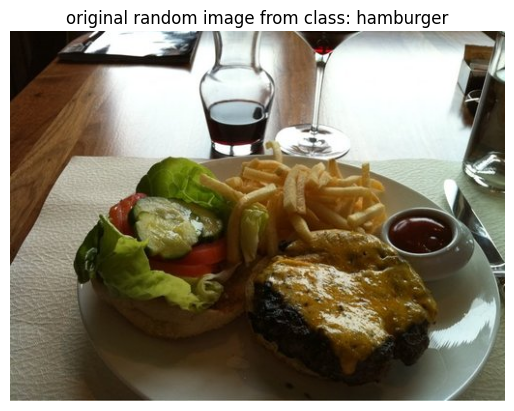

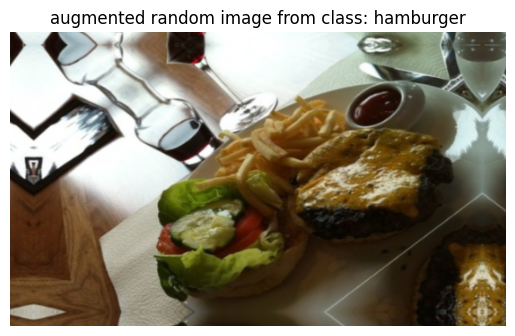

In [32]:
# view random image and compare with original image
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os
import random
target_class = random.choice(train_data_1_percent.class_names)
target_dir = "10_food_classes_1_percent/train/" + target_class
random_image = random.choice(os.listdir(target_dir))
random_image_path = os.path.join(target_dir,random_image)
img = mpimg.imread(random_image_path)
plt.imshow(img)
plt.title(f"original random image from class: {target_class}")
plt.axis(False)
plt.figure();
augmented_imag = data_augmentation(img)
print(augmented_imag.shape)
plt.imshow(augmented_imag/255.)
plt.title(f"augmented random image from class: {target_class}")
plt.axis(False)


## Model 1: feature extraction transfer learning with 1% of the data with data augmentation

In [33]:
#data augmentation with functional layers
# Recommended way for TF ≥ 2.17
inputs = tf.keras.Input(shape=(224, 224, 3), name="input_layer")

# Apply augmentation functionally (not in a Sequential)
x = tf.keras.layers.RandomFlip("horizontal")(inputs)
x = tf.keras.layers.RandomRotation(0.2)(x)
x = tf.keras.layers.RandomHeight(0.2)(x)
x = tf.keras.layers.RandomWidth(0.2)(x)
x = tf.keras.layers.RandomZoom(0.1, 0.15)(x)
# Setup input shape and base_model
input_shape = (224,224,3)
base_model = tf.keras.applications.EfficientNetB0(include_top=False,input_shape=(224,224,3))
base_model.trainable = False

# Create the input layer
# inputs = layers.Input(shape=input_shape,name="input_layer")

# add in data augmentation Sequential model as a layer
# x = data_augmentation(inputs)

# Give base_model the inputs( after augmentation) and don't train it
x = base_model(x,training=False)

# pool output features of the base model
x = layers.GlobalAveragePooling2D(name="global_average_pooling_layer")(x)

# put a dense layer on as the output
outputs = layers.Dense(10,activation="softmax",name="output_layer")(x)

# Make a model using the inputs and outputs
model_1 = keras.Model(inputs=inputs,outputs=outputs)

# compile the model
model_1.compile(loss="categorical_crossentropy",
                optimizer=tf.keras.optimizers.Adam(),
                metrics=["accuracy"])
# fit the model
model_1_history = model_1.fit(train_data_1_percent,
                              epochs=5,
                              steps_per_epoch=len(train_data_1_percent),
                              validation_data=test_data,
                              validation_steps=(int(0.25*len(test_data))),
                              callbacks=[create_tensorboard_callback("TensorFlow_Hub","1_percent_data_exprt")]
                              )










Saving TensorBoard log files to: TensorFlow_Hub/1_percent_data_exprt/20260131-120812
Epoch 1/5
3/3 ━━━━━━━━━━━━━━━━━━━━ 19s 3s/step - accuracy: 0.1417 - loss: 2.2946 - val_accuracy: 0.2056 - val_loss: 2.1498
Epoch 2/5
3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 796ms/step - accuracy: 0.2874 - loss: 2.0080 - val_accuracy: 0.3158 - val_loss: 1.9976
Epoch 3/5
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 792ms/step - accuracy: 0.4551 - loss: 1.8487 - val_accuracy: 0.3635 - val_loss: 1.9031
Epoch 4/5
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 1s/step - accuracy: 0.6086 - loss: 1.6419 - val_accuracy: 0.4441 - val_loss: 1.8021
Epoch 5/5
3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 807ms/step - accuracy: 0.6151 - loss: 1.6037 - val_accuracy: 0.4934 - val_loss: 1.7096


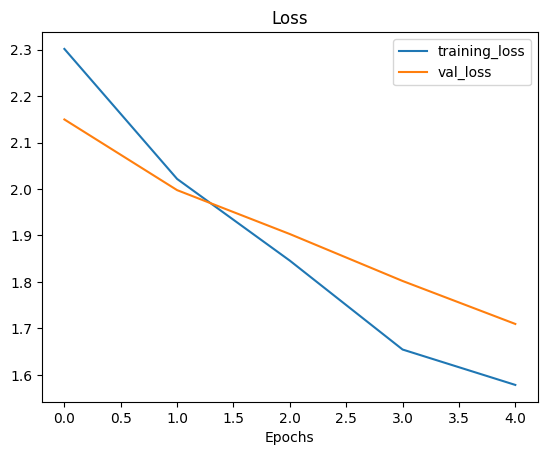

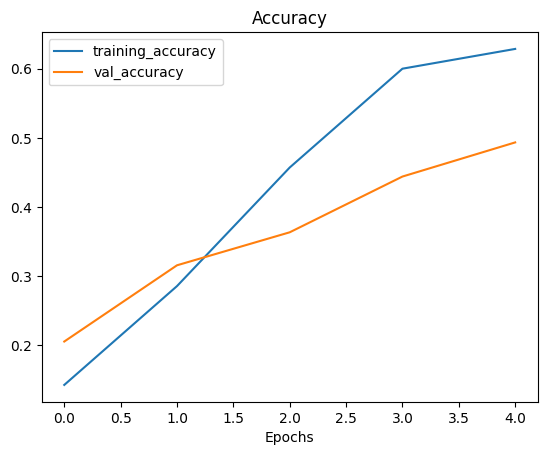

In [34]:
plot_loss_curves(model_1_history)

In [35]:
model_1.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_flip_1 (RandomFlip)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation_1               │ (None, 224, 224, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_height_1 (RandomHeight)  │ (None, None, 224, 3)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_width_1 (RandomWidth)    │ (None, None, None, 3)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom_1 (RandomZoom)      │ (None, None, None, 3)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, None, None,     │     4,049,571 │
│                                 │ 1280)                  │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling_layer    │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 10)             │        12,810 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,088,003 (15.59 MB)

 Trainable params: 12,810 (50.04 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

 Optimizer params: 25,622 (100.09 KB)

In [36]:
# Evaluate with test dataset
model_1.evaluate(test_data)

79/79 ━━━━━━━━━━━━━━━━━━━━ 6s 79ms/step - accuracy: 0.4988 - loss: 1.7191


[1.7203304767608643, 0.5004000067710876]

## Model 2: feature extraction transfer learning model with 10% of data and data augmentation

In [37]:
# Get 10% of data
train_dir_10_percent = "/content/10_food_classes_10_percent/train"
test_dir = "/content/10_food_classes_10_percent/test"


In [38]:
# Set data inputs
IMG_SIZE = (224,224)
train_data_10_percent = tf.keras.preprocessing.image_dataset_from_directory(train_dir_10_percent,
                                                                            label_mode="categorical",
                                                                            image_size=IMG_SIZE
                                                                            )
test_data = tf.keras.preprocessing.image_dataset_from_directory(test_dir,
                                                                label_mode="categorical",
                                                                image_size=IMG_SIZE)

Found 750 files belonging to 10 classes.


Found 2500 files belonging to 10 classes.


In [39]:
# Create model 2 with data augmentation built in
from tensorflow.keras import layers
inputs = layers.Input(shape=(224,224,3),name="input_layer")
x = layers.RandomFlip("horizontal")(inputs)
x = layers.RandomHeight(0.2)(x)
x = layers.RandomWidth(0.2)(x)
x = layers.RandomZoom(0.2)(x)
x = layers.RandomRotation(0.2)(x)

# setup the input shape to our model
input_shape = (224,224,3)
# create a frozen base model
base_model = tf.keras.applications.EfficientNetB0(include_top=False)
base_model.trainable = False
x = base_model(x,training=False)
x = layers.GlobalAveragePooling2D(name="Global_average_pooling_layer")(x)
outputs =  layers.Dense(10,activation="softmax",name="output_layer")(x)
model_2 = tf.keras.Model(inputs,outputs)

# compile the model
model_2.compile(loss="categorical_crossentropy",
                optimizer="adam",
                metrics=["accuracy"])

# Fit the model
model_2_history = model_2.fit(train_data_10_percent,
                              epochs=5,
                              steps_per_epoch=len(train_data_10_percent),
                              validation_data=test_data,
                              validation_steps=int(0.25*len(test_data)))



Epoch 1/5
24/24 ━━━━━━━━━━━━━━━━━━━━ 18s 309ms/step - accuracy: 0.2363 - loss: 2.1748 - val_accuracy: 0.7253 - val_loss: 1.3864
Epoch 2/5
24/24 ━━━━━━━━━━━━━━━━━━━━ 4s 187ms/step - accuracy: 0.6793 - loss: 1.4023 - val_accuracy: 0.7977 - val_loss: 0.9822
Epoch 3/5
24/24 ━━━━━━━━━━━━━━━━━━━━ 5s 188ms/step - accuracy: 0.7730 - loss: 1.0535 - val_accuracy: 0.8207 - val_loss: 0.7860
Epoch 4/5
24/24 ━━━━━━━━━━━━━━━━━━━━ 5s 184ms/step - accuracy: 0.7857 - loss: 0.8910 - val_accuracy: 0.8388 - val_loss: 0.7039
Epoch 5/5
24/24 ━━━━━━━━━━━━━━━━━━━━ 5s 200ms/step - accuracy: 0.8204 - loss: 0.7583 - val_accuracy: 0.8536 - val_loss: 0.6073


In [40]:
# set checkpoint path
checkpoint_path = "ten_percent_checkpoints_weights/ckpt/checkpoint.weights.h5"
checkpoint_callback = tf.keras.callbacks.ModelCheckpoint(filepath=checkpoint_path,
                                                        save_weights_only=True,
                                                        save_best_only=False,
                                                        # monitors="val_accuracy",
                                                        mode="max",
                                                        save_freq="epoch",
                                                        verbose=1
                                                        )

In [41]:
# fit the model saving checkpoints every epoch
initial_epochs = 5
model_2_history = model_2.fit(train_data_10_percent,
                              epochs=initial_epochs,
                              steps_per_epoch=len(train_data_10_percent),
                              validation_data=test_data,
                              validation_steps=int(0.25*len(test_data)),
                              callbacks=[create_tensorboard_callback("TensorFlow_Hub","10_percent_data_aug"),checkpoint_callback]
                              )


Saving TensorBoard log files to: TensorFlow_Hub/10_percent_data_aug/20260131-120933
Epoch 1/5


24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step - accuracy: 0.8494 - loss: 0.6891
Epoch 1: saving model to ten_percent_checkpoints_weights/ckpt/checkpoint.weights.h5
24/24 ━━━━━━━━━━━━━━━━━━━━ 5s 203ms/step - accuracy: 0.8488 - loss: 0.6892 - val_accuracy: 0.8569 - val_loss: 0.5742
Epoch 2/5
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step - accuracy: 0.8411 - loss: 0.6395
Epoch 2: saving model to ten_percent_checkpoints_weights/ckpt/checkpoint.weights.h5
24/24 ━━━━━━━━━━━━━━━━━━━━ 5s 228ms/step - accuracy: 0.8404 - loss: 0.6401 - val_accuracy: 0.8553 - val_loss: 0.5615
Epoch 3/5
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step - accuracy: 0.8129 - loss: 0.6345
Epoch 3: saving model to ten_percent_checkpoints_weights/ckpt/checkpoint.weights.h5
24/24 ━━━━━━━━━━━━━━━━━━━━ 5s 196ms/step - accuracy: 0.8138 - loss: 0.6332 - val_accuracy: 0.8553 - val_loss: 0.5351
Epoch 4/5
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step - accuracy: 0.8615 - loss: 0.5840
Epoch 4: saving model to ten_percent_checkpoints_weights/ckpt/check

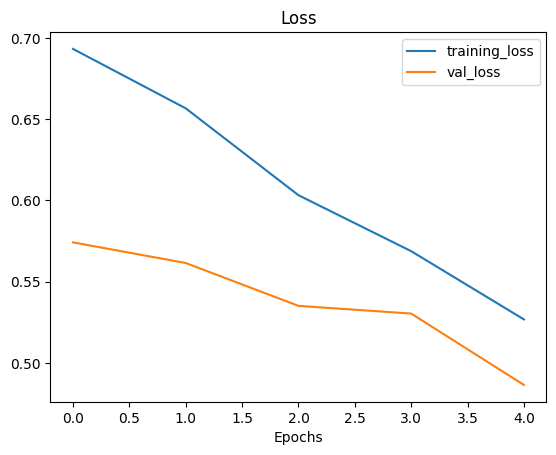

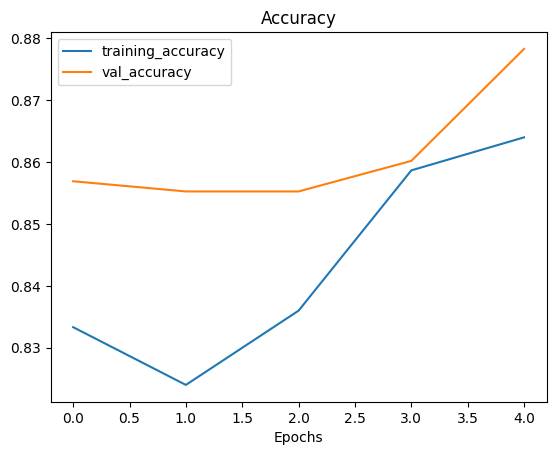

In [42]:
plot_loss_curves(model_2_history)

In [43]:
model_0.evaluate(test_data)

 1/79 ━━━━━━━━━━━━━━━━━━━━ 7s 95ms/step - accuracy: 0.9375 - loss: 0.5668

79/79 ━━━━━━━━━━━━━━━━━━━━ 4s 56ms/step - accuracy: 0.8576 - loss: 0.5612


[0.5555949807167053, 0.8583999872207642]

In [44]:
results_10_percent = model_2.evaluate(test_data)

79/79 ━━━━━━━━━━━━━━━━━━━━ 6s 81ms/step - accuracy: 0.8691 - loss: 0.4890


In [45]:
# Load in saved model and evaluate model
model_2.load_weights(checkpoint_path)


In [46]:
loaded_weights_model_result = model_2.evaluate(test_data)

79/79 ━━━━━━━━━━━━━━━━━━━━ 6s 74ms/step - accuracy: 0.8672 - loss: 0.4983


In [47]:
results_10_percent == loaded_weights_model_result

False

In [48]:
results_10_percent,loaded_weights_model_result

([0.4991060197353363, 0.8611999750137329],
 [0.49910596013069153, 0.8611999750137329])

In [49]:
import numpy as np
np.isclose(np.array(results_10_percent),np.array(loaded_weights_model_result))

array([ True,  True])

## Model 3: Fine-tuning an existing model on 10% of the data
**Note:** Fine-tuning usually works best after training a feature extraction model for a few epochs with large amounts of custom data

In [50]:
model_2.layers

[<InputLayer name=input_layer, built=True>,
 <RandomFlip name=random_flip_2, built=True>,
 <RandomHeight name=random_height_2, built=True>,
 <RandomWidth name=random_width_2, built=True>,
 <RandomZoom name=random_zoom_2, built=True>,
 <RandomRotation name=random_rotation_2, built=True>,
 <Functional name=efficientnetb0, built=True>,
 <GlobalAveragePooling2D name=Global_average_pooling_layer, built=True>,
 <Dense name=output_layer, built=True>]

In [51]:
for layer in model_2.layers:
  print(layer,layer.trainable)


<InputLayer name=input_layer, built=True> True
<RandomFlip name=random_flip_2, built=True> True
<RandomHeight name=random_height_2, built=True> True
<RandomWidth name=random_width_2, built=True> True
<RandomZoom name=random_zoom_2, built=True> True
<RandomRotation name=random_rotation_2, built=True> True
<Functional name=efficientnetb0, built=True> False
<GlobalAveragePooling2D name=Global_average_pooling_layer, built=True> True
<Dense name=output_layer, built=True> True


In [52]:
for i, layer in enumerate(model_2.layers[6].layers):
  print(i,layer.name,layer.trainable)

0 input_layer_4 False
1 rescaling_4 False
2 normalization_2 False
3 rescaling_5 False
4 stem_conv_pad False
5 stem_conv False
6 stem_bn False
7 stem_activation False
8 block1a_dwconv False
9 block1a_bn False
10 block1a_activation False
11 block1a_se_squeeze False
12 block1a_se_reshape False
13 block1a_se_reduce False
14 block1a_se_expand False
15 block1a_se_excite False
16 block1a_project_conv False
17 block1a_project_bn False
18 block2a_expand_conv False
19 block2a_expand_bn False
20 block2a_expand_activation False
21 block2a_dwconv_pad False
22 block2a_dwconv False
23 block2a_bn False
24 block2a_activation False
25 block2a_se_squeeze False
26 block2a_se_reshape False
27 block2a_se_reduce False
28 block2a_se_expand False
29 block2a_se_excite False
30 block2a_project_conv False
31 block2a_project_bn False
32 block2b_expand_conv False
33 block2b_expand_bn False
34 block2b_expand_activation False
35 block2b_dwconv False
36 block2b_bn False
37 block2b_activation False
38 block2b_se_squeez

In [53]:
print(len(model_2.layers[6].trainable_variables))

0


In [54]:
# clone model_2
model_3 = tf.keras.models.clone_model(model_2)
#build
model_3.build(model_2.input_shape)
# used model_2 weights
model_3.set_weights(model_2.get_weights())

In [55]:
model_3.summary(),model_2.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_flip_2 (RandomFlip)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_height_2 (RandomHeight)  │ (None, None, 224, 3)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_width_2 (RandomWidth)    │ (None, None, None, 3)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom_2 (RandomZoom)      │ (None, None, None, 3)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation_2               │ (None, None, None, 3)  │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, None, None,     │     4,049,571 │
│                                 │ 1280)                  │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Global_average_pooling_layer    │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 10)             │        12,810 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,088,003 (15.59 MB)

 Trainable params: 12,810 (50.04 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

...

 Total params: 4,088,003 (15.59 MB)

 Trainable params: 12,810 (50.04 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

 Optimizer params: 25,622 (100.09 KB)

(None, None)

In [56]:
# Unfreeze the base model first
model_3.layers[6].trainable = True

# Freeze all layers except the last 10 in the base model
for layer in model_3.layers[6].layers[:-10]:
  layer.trainable = False
for layer in model_3.layers[6].layers[-10:]:
  layer.trainable = True

In [57]:
len(model_3.layers[6].trainable_variables)

10

In [58]:
for i, layer in enumerate(model_3.layers[6].layers):
  print(i,layer.name,layer.trainable)

0 input_layer_4 False
1 rescaling_4 False
2 normalization_2 False
3 rescaling_5 False
4 stem_conv_pad False
5 stem_conv False
6 stem_bn False
7 stem_activation False
8 block1a_dwconv False
9 block1a_bn False
10 block1a_activation False
11 block1a_se_squeeze False
12 block1a_se_reshape False
13 block1a_se_reduce False
14 block1a_se_expand False
15 block1a_se_excite False
16 block1a_project_conv False
17 block1a_project_bn False
18 block2a_expand_conv False
19 block2a_expand_bn False
20 block2a_expand_activation False
21 block2a_dwconv_pad False
22 block2a_dwconv False
23 block2a_bn False
24 block2a_activation False
25 block2a_se_squeeze False
26 block2a_se_reshape False
27 block2a_se_reduce False
28 block2a_se_expand False
29 block2a_se_excite False
30 block2a_project_conv False
31 block2a_project_bn False
32 block2b_expand_conv False
33 block2b_expand_bn False
34 block2b_expand_activation False
35 block2b_dwconv False
36 block2b_bn False
37 block2b_activation False
38 block2b_se_squeez

In [59]:
# Recompile (  we have to recompile our models every time we make a change)
model_3.compile(loss="categorical_crossentropy",
                optimizer=tf.keras.optimizers.Adam(2e-4),
                metrics=["accuracy"])

In [60]:
# Check which layers are tunable
for layer in model_3.layers:
  print(layer,layer.trainable)
for layer_number, layer in enumerate(model_3.layers[6].layers):
  print(layer_number,layer.name,layer.trainable)

<InputLayer name=input_layer, built=True> True
<RandomFlip name=random_flip_2, built=True> True
<RandomHeight name=random_height_2, built=True> True
<RandomWidth name=random_width_2, built=True> True
<RandomZoom name=random_zoom_2, built=True> True
<RandomRotation name=random_rotation_2, built=True> True
<Functional name=efficientnetb0, built=True> True
<GlobalAveragePooling2D name=Global_average_pooling_layer, built=True> True
<Dense name=output_layer, built=True> True
0 input_layer_4 False
1 rescaling_4 False
2 normalization_2 False
3 rescaling_5 False
4 stem_conv_pad False
5 stem_conv False
6 stem_bn False
7 stem_activation False
8 block1a_dwconv False
9 block1a_bn False
10 block1a_activation False
11 block1a_se_squeeze False
12 block1a_se_reshape False
13 block1a_se_reduce False
14 block1a_se_expand False
15 block1a_se_excite False
16 block1a_project_conv False
17 block1a_project_bn False
18 block2a_expand_conv False
19 block2a_expand_bn False
20 block2a_expand_activation False
21 

In [61]:
# fine tune model_3 with 10 percent of training data
fine_tune_epochs = 5
total_epochs = initial_epochs + fine_tune_epochs
model_3_history = model_3.fit(train_data_10_percent,
                              epochs=total_epochs,
                              initial_epoch=model_2_history.epoch[-1],
                              steps_per_epoch=len(train_data_10_percent),
                              validation_data=test_data,
                              validation_steps=int(0.25*len(test_data)),
                              callbacks=[create_tensorboard_callback("TensorFlow_Hub","10_percent_fine_tune")]
                              )

Saving TensorBoard log files to: TensorFlow_Hub/10_percent_fine_tune/20260131-121028
Epoch 5/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 20s 320ms/step - accuracy: 0.7808 - loss: 0.7634 - val_accuracy: 0.8372 - val_loss: 0.5390
Epoch 6/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 5s 220ms/step - accuracy: 0.8531 - loss: 0.5743 - val_accuracy: 0.8240 - val_loss: 0.5314
Epoch 7/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 5s 187ms/step - accuracy: 0.8682 - loss: 0.5227 - val_accuracy: 0.8273 - val_loss: 0.5134
Epoch 8/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 4s 180ms/step - accuracy: 0.9029 - loss: 0.4488 - val_accuracy: 0.8339 - val_loss: 0.4960
Epoch 9/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 10s 405ms/step - accuracy: 0.8902 - loss: 0.4225 - val_accuracy: 0.8372 - val_loss: 0.5040
Epoch 10/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 4s 182ms/step - accuracy: 0.9142 - loss: 0.3641 - val_accuracy: 0.8224 - val_loss: 0.5240


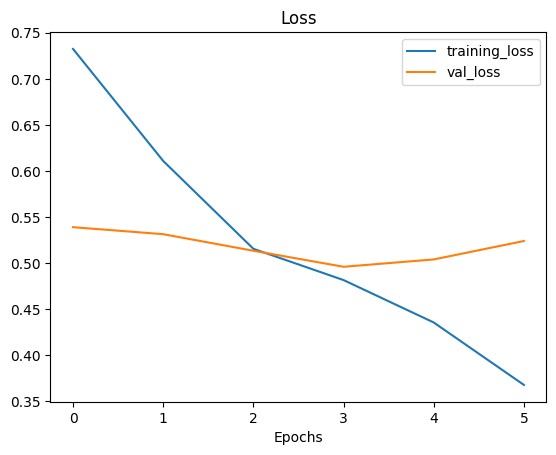

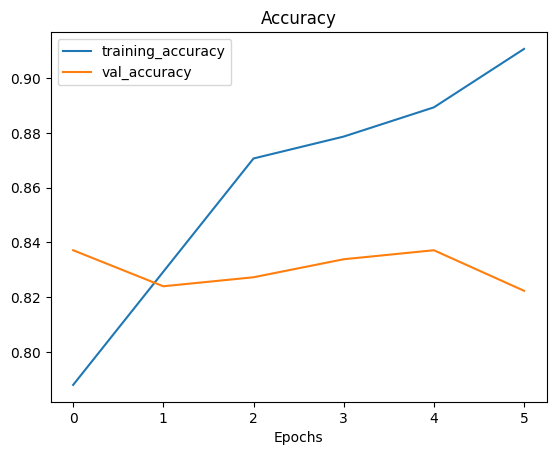

In [62]:
# visualize model_3 loss and accuracy curves
plot_loss_curves(model_3_history)

In [63]:
!ls

10_food_classes_10_percent	__MACOSX
10_food_classes_10_percent.zip	__pycache__
10_food_classes_1_percent	sample_data
10_food_classes_1_percent.zip	ten_percent_checkpoints_weights
helper_functions.py		TensorFlow_Hub
helper_functions.py.1



## Model_4 fine tuning with  100% of 10 class data

In [64]:
!wget https://storage.googleapis.com/ztm_tf_course/food_vision/10_food_classes_all_data.zip

--2026-01-31 12:11:20--  https://storage.googleapis.com/ztm_tf_course/food_vision/10_food_classes_all_data.zip
Resolving storage.googleapis.com (storage.googleapis.com)... 142.251.18.207, 192.178.156.207, 192.178.213.207, ...
Connecting to storage.googleapis.com (storage.googleapis.com)|142.251.18.207|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 519183241 (495M) [application/zip]
Saving to: ‘10_food_classes_all_data.zip’

10_food_classes_all 100%[===================>] 495.13M  41.3MB/s    in 13s     

2026-01-31 12:11:34 (37.4 MB/s) - ‘10_food_classes_all_data.zip’ saved [519183241/519183241]



In [104]:
# load all data
unzip_data("10_food_classes_all_data.zip")




In [106]:
walk_through_dir("10_food_classes_all_data")

There are 2 directories and 0 images in '10_food_classes_all_data'.
There are 10 directories and 0 images in '10_food_classes_all_data/test'.
There are 0 directories and 250 images in '10_food_classes_all_data/test/chicken_curry'.
There are 0 directories and 250 images in '10_food_classes_all_data/test/ramen'.
There are 0 directories and 250 images in '10_food_classes_all_data/test/ice_cream'.
There are 0 directories and 250 images in '10_food_classes_all_data/test/pizza'.
There are 0 directories and 250 images in '10_food_classes_all_data/test/steak'.
There are 0 directories and 250 images in '10_food_classes_all_data/test/fried_rice'.
There are 0 directories and 250 images in '10_food_classes_all_data/test/hamburger'.
There are 0 directories and 250 images in '10_food_classes_all_data/test/grilled_salmon'.
There are 0 directories and 250 images in '10_food_classes_all_data/test/chicken_wings'.
There are 0 directories and 250 images in '10_food_classes_all_data/test/sushi'.
There are 

In [107]:
# load training and testing data
train_dir = "10_food_classes_all_data/train"
test_dir = "10_food_classes_all_data/test"
# Set up data loader
IMG_SIZE = (224,224)
BATCH_SIZE = 32 
train_data_all = tf.keras.preprocessing.image_dataset_from_directory(directory=train_dir,
                                                                    image_size=IMG_SIZE,
                                                                    label_mode='categorical',
                                                                    batch_size=BATCH_SIZE
                                                                    )
test_data = tf.keras.preprocessing.image_dataset_from_directory(directory=test_dir,
                                                                  image_size=IMG_SIZE,
                                                                  batch_size=BATCH_SIZE,
                                                                  label_mode="categorical")

Found 7500 files belonging to 10 classes.
Found 2500 files belonging to 10 classes.


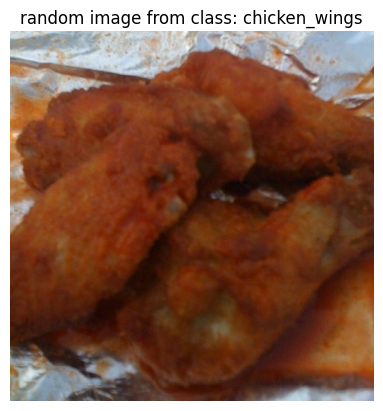

In [114]:
#visualize random image
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os
import random   
target_class = random.choice(train_data_all.class_names)
target_dir = "10_food_classes_all_data/train/" + target_class   

random_image = random.choice(os.listdir(target_dir))
random_image_path = os.path.join(target_dir,random_image)
img = mpimg.imread(random_image_path)
plt.imshow(img)
plt.title(f"random image from class: {target_class}")
plt.axis(False);
plt.show()



In [109]:
# import EfficientNetB0 and preprocessing layer
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input

In [89]:
# model_4 with EfficientNetB0 base model and all data
# setup the input shape to our model
input_shape = (224,224,3)
# create a frozen base model
base_model = tf.keras.applications.EfficientNetB0(include_top=False,weights='imagenet',input_shape=(224,224,3))
base_model.trainable = False

# create the input layer
input_layer = tf.keras.layers.Input(shape=input_shape,name="input_layer")
# preprocessing layer
inputs = preprocess_input(input_layer)
# data augmentation layer
x = tf.keras.layers.RandomFlip("horizontal")(inputs)  
x = tf.keras.layers.RandomRotation(0.2)(x)
x = tf.keras.layers.RandomHeight(0.2)(x)
x = tf.keras.layers.RandomWidth(0.2)(x)
x = tf.keras.layers.RandomZoom(0.2)(x)
# pass augmented data to base model
x = base_model(x,training=False)
x = tf.keras.layers.GlobalAveragePooling2D(name="Global_average_pooling_layer")(x)
outputs =  tf.keras.layers.Dense(10,activation="softmax",name="output_layer")(x)
model_4 = tf.keras.Model(inputs,outputs)


In [110]:
# feature Extraction model_4
model_4.compile(loss="categorical_crossentropy",
                optimizer=tf.keras.optimizers.Adam(),
                metrics=["accuracy"])



In [112]:
# train model_4 for 5 epoch to get pattern for feature extractor layer
model_4_feature_extractor_history = model_4.fit(train_data_all,
                              epochs=5,
                              steps_per_epoch=len(train_data_all),
                              validation_data=test_data,
                              validation_steps=int(0.25*len(test_data)),
                              callbacks=[create_tensorboard_callback("TensorFlow_Hub","all_data_exprt")]
                              )

Saving TensorBoard log files to: TensorFlow_Hub/all_data_exprt/20260131-124032
Epoch 1/5


235/235 ━━━━━━━━━━━━━━━━━━━━ 29s 122ms/step - accuracy: 0.9312 - loss: 0.2038 - val_accuracy: 0.8914 - val_loss: 0.3991
Epoch 2/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 41s 122ms/step - accuracy: 0.9314 - loss: 0.1996 - val_accuracy: 0.8865 - val_loss: 0.4529
Epoch 3/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 38s 109ms/step - accuracy: 0.9430 - loss: 0.1748 - val_accuracy: 0.8947 - val_loss: 0.3541
Epoch 4/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 26s 111ms/step - accuracy: 0.9478 - loss: 0.1533 - val_accuracy: 0.8816 - val_loss: 0.4529
Epoch 5/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 25s 106ms/step - accuracy: 0.9546 - loss: 0.1387 - val_accuracy: 0.9178 - val_loss: 0.2917


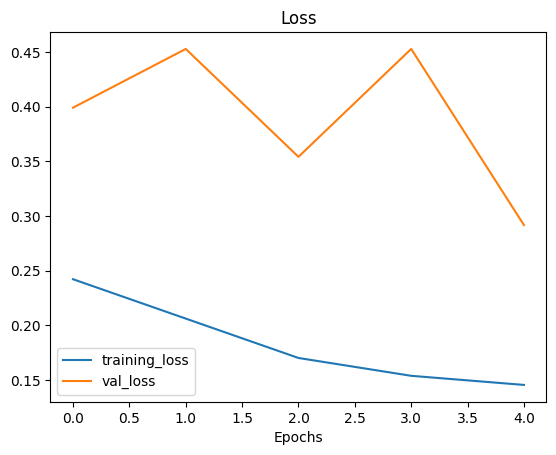

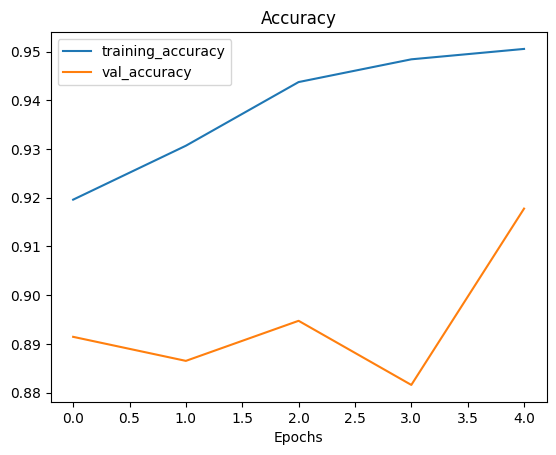

In [113]:
# visualize model_4 feature extractor loss and accuracy curves
plot_loss_curves(model_4_feature_extractor_history)

In [93]:
# visualize model_4 trainable and non-trainable layers
for layer in model_4.layers:
  print(layer,layer.trainable)

<InputLayer name=input_layer, built=True> True
<RandomFlip name=random_flip_6, built=True> True
<RandomRotation name=random_rotation_6, built=True> True
<RandomHeight name=random_height_6, built=True> True
<RandomWidth name=random_width_6, built=True> True
<RandomZoom name=random_zoom_6, built=True> True
<Functional name=efficientnetb0, built=True> False
<GlobalAveragePooling2D name=Global_average_pooling_layer, built=True> True
<Dense name=output_layer, built=True> True


In [95]:
# unfreeze top 10 layers
for layer in model_4.layers[6].layers[-10:]:
    layer.trainable = True
# visualize model_4 trainable and non-trainable layers
for layer in model_4.layers[6].layers[-15:]:
    print(layer,layer.trainable)


<BatchNormalization name=block7a_expand_bn, built=True> False
<Activation name=block7a_expand_activation, built=True> False
<DepthwiseConv2D name=block7a_dwconv, built=True> False
<BatchNormalization name=block7a_bn, built=True> False
<Activation name=block7a_activation, built=True> False
<GlobalAveragePooling2D name=block7a_se_squeeze, built=True> True
<Reshape name=block7a_se_reshape, built=True> True
<Conv2D name=block7a_se_reduce, built=True> True
<Conv2D name=block7a_se_expand, built=True> True
<Multiply name=block7a_se_excite, built=True> True
<Conv2D name=block7a_project_conv, built=True> True
<BatchNormalization name=block7a_project_bn, built=True> True
<Conv2D name=top_conv, built=True> True
<BatchNormalization name=top_bn, built=True> True
<Activation name=top_activation, built=True> True


In [96]:
# compile model_4 for fine-tuning
model_4.compile(loss="categorical_crossentropy",
                optimizer=tf.keras.optimizers.Adam(2e-4),
                metrics=["accuracy"])


In [99]:
# fine tune model_4 with all data
fine_tune_epochs = 5
total_epochs = 5 + fine_tune_epochs
model_4_fine_tune_history = model_4.fit(train_data_all,
                              epochs=total_epochs,
                              initial_epoch=model_4_feature_extractor_history.epoch[-1],
                              steps_per_epoch=len(train_data_all),
                              validation_data=test_data,
                              validation_steps=int(0.25*len(test_data)),
                              callbacks=[create_tensorboard_callback("TensorFlow_Hub","all_data_fine_tune")]
                              )

Saving TensorBoard log files to: TensorFlow_Hub/all_data_fine_tune/20260131-123317
Epoch 5/10


235/235 ━━━━━━━━━━━━━━━━━━━━ 26s 112ms/step - accuracy: 0.9186 - loss: 0.2509 - val_accuracy: 0.9095 - val_loss: 0.3152
Epoch 6/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 41s 113ms/step - accuracy: 0.9287 - loss: 0.2283 - val_accuracy: 0.9030 - val_loss: 0.3233
Epoch 7/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 26s 111ms/step - accuracy: 0.9407 - loss: 0.2036 - val_accuracy: 0.9013 - val_loss: 0.3121
Epoch 8/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 26s 111ms/step - accuracy: 0.9441 - loss: 0.1838 - val_accuracy: 0.9046 - val_loss: 0.2960
Epoch 9/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 41s 109ms/step - accuracy: 0.9473 - loss: 0.1772 - val_accuracy: 0.9095 - val_loss: 0.2980
Epoch 10/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 41s 109ms/step - accuracy: 0.9543 - loss: 0.1656 - val_accuracy: 0.8931 - val_loss: 0.3397


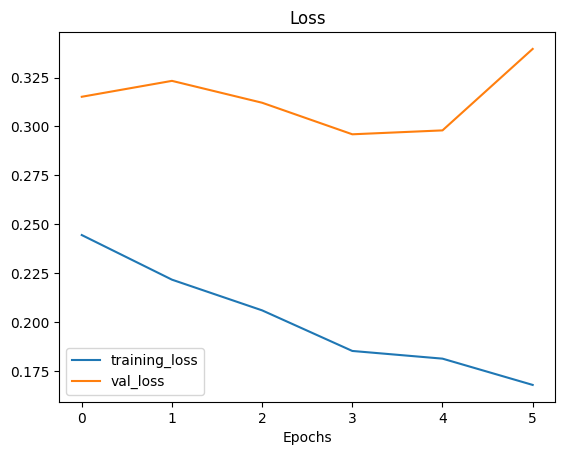

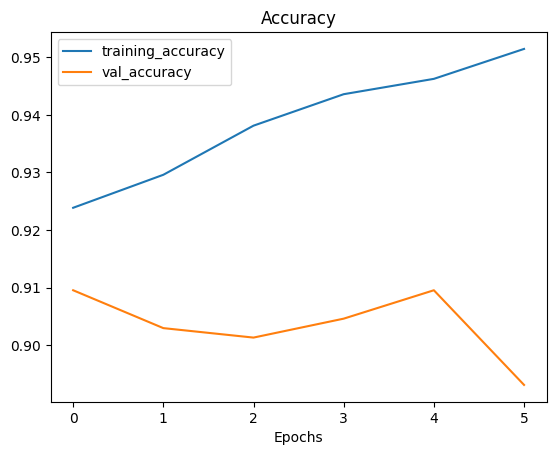

In [100]:
# visualize fine tuned model_4 loss curves
plot_loss_curves(model_4_fine_tune_history)

In [118]:
# evaluate model_4 on test data
model_4.evaluate(test_data)

79/79 ━━━━━━━━━━━━━━━━━━━━ 6s 79ms/step - accuracy: 0.9121 - loss: 0.3246


[0.31194597482681274, 0.9143999814987183]

In [117]:
# save model_4 as SavedModel format
model_4.export("saved_models/food_vision_model_4")


Saved artifact at 'saved_models/food_vision_model_4'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='input_layer')
Output Type:
  TensorSpec(shape=(None, 10), dtype=tf.float32, name=None)
Captures:
  139725624545104: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139725624544336: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139725156859344: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139725155958864: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139725155959824: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139725155959248: TensorSpec(shape=(1, 1, 1, 3), dtype=tf.float32, name=None)
  139725155959056: TensorSpec(shape=(1, 1, 1, 3), dtype=tf.float32, name=None)
  139725624545488: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139725624545296: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139725624545872: TensorSpec(shape=(), dtype=tf.res

In [ ]:
# load the saved model
loaded_model_4 = keras.layers.TFSMLayer("saved_models/food_vision_model_4", call_endpoint='serve')

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 10), dtype=tf.float32, name=None))>

In [131]:
x_batch, y_batch = next(iter(test_data))
preds = loaded_model_4(x_batch)


In [132]:
preds

<tf.Tensor: shape=(32, 10), dtype=float32, numpy=
array([[2.37405766e-03, 1.15728246e-04, 3.99171840e-05, 2.15826891e-04,
        1.73668632e-05, 1.28303981e-07, 9.97208178e-01, 9.58851160e-07,
        1.05425097e-05, 1.72703094e-05],
       [3.18822998e-07, 6.55343442e-08, 2.63407810e-06, 1.90719007e-07,
        7.47875595e-10, 9.99992251e-01, 7.60457112e-07, 3.42506928e-06,
        3.79945647e-07, 1.36804239e-08],
       [9.44738805e-01, 6.73652976e-04, 4.57162416e-04, 1.13229053e-02,
        3.37476755e-04, 5.98449162e-07, 1.60965286e-02, 2.60674767e-02,
        2.69200304e-04, 3.60795530e-05],
       [4.63309448e-07, 2.82675348e-04, 9.56690565e-06, 9.37749974e-06,
        7.39291136e-05, 9.99251306e-01, 1.51319051e-04, 1.89153507e-04,
        1.60587160e-06, 3.05761678e-05],
       [2.81962939e-03, 4.98714962e-06, 3.71156602e-05, 9.93869305e-01,
        2.13263076e-04, 3.23375526e-09, 3.71841952e-06, 1.33574383e-06,
        3.03202611e-03, 1.85240497e-05],
       [9.68362987e-01, 1

In [135]:
# compare predicted labels and true labels
import numpy as np
pred_classes = tf.argmax(preds,axis=1)
true_classes = tf.argmax(y_batch,axis=1)
pred_classes == true_classes, pred_classes, true_classes


(<tf.Tensor: shape=(32,), dtype=bool, numpy=
 array([ True,  True, False,  True,  True,  True,  True, False,  True,
        False,  True,  True,  True,  True,  True,  True,  True, False,
         True,  True,  True, False,  True, False,  True,  True,  True,
         True,  True,  True,  True, False])>,
 <tf.Tensor: shape=(32,), dtype=int64, numpy=
 array([6, 5, 0, 5, 3, 0, 0, 5, 4, 2, 6, 1, 1, 3, 3, 9, 7, 3, 4, 7, 7, 1,
        6, 8, 2, 0, 7, 0, 7, 9, 0, 5])>,
 <tf.Tensor: shape=(32,), dtype=int64, numpy=
 array([6, 5, 7, 5, 3, 0, 0, 8, 4, 9, 6, 1, 1, 3, 3, 9, 7, 2, 4, 7, 7, 0,
        6, 3, 2, 0, 7, 0, 7, 9, 0, 4])>)

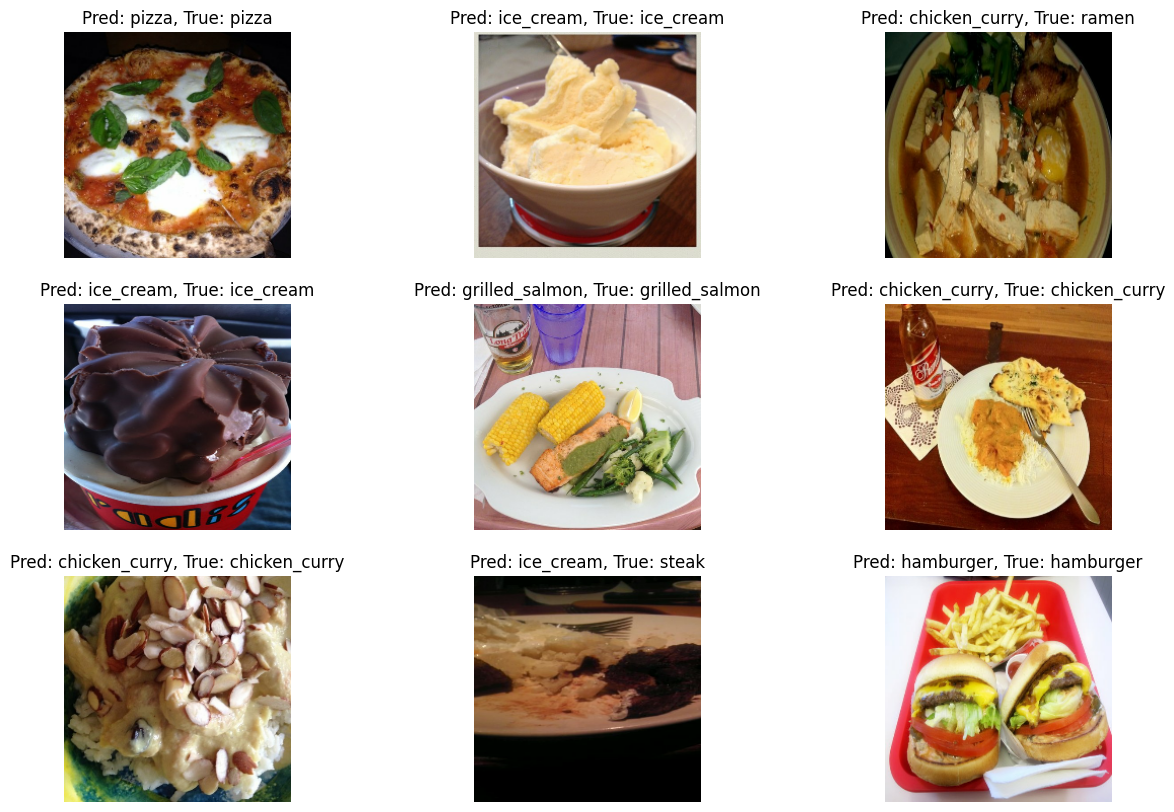

In [137]:
#visualize using matplotlib predicted labels and true labels with their class names showing the food image graphically
class_names = train_data_all.class_names
plt.figure(figsize=(15,10))
for i in range(9):  
    plt.subplot(3,3,i+1)
    plt.imshow(x_batch[i].numpy().astype("uint8"))
    plt.title(f"Pred: {class_names[pred_classes[i]]}, True: {class_names[true_classes[i]]}")
    plt.axis(False)
    

